The purpose of this notebook is to guide you through how to use BifurcationKit to study the Jansen-Rit model. The aim of this tutorial is to reproduce Figures 22 and 24 in the paper by Grimbert and Faugueras.


Before we do anything, we need to import some packages.

In [ ]:
using Revise, Plots
using BifurcationKit

The equations to the system are below. The first step is the define the sytem in the jansenrit function.

Then we must assign the paramter values. We use the same parameter values used in the paper. p will be our control parameter. We still need to give it a value. This value will be the starting value that BifurcationKit will use for the bifurcation analysis.

We also need initial conditions for each functio. (TBH I don't understand why?)

Finally we define the Bifurcation problem, for which we need the jansenrit function, the parameter values, and the initial conditions. We also define the control parameter with (@optic _.p). If a was our control parameter, we would say (@optic _.a). Lastly, with record_from_solution, we tell bifurcation kit which values we want to be able to access. 

I just put all of them. And I also added y = y1-y2 so that we can access that directly.

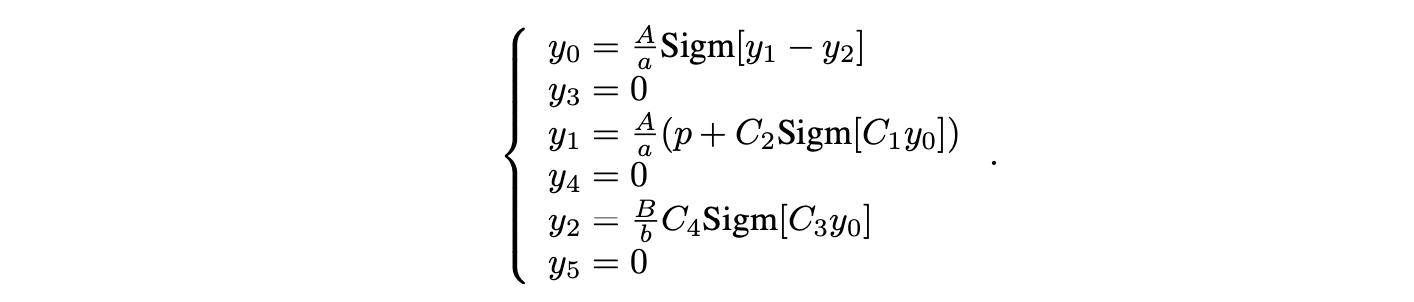

In [ ]:
const BK = BifurcationKit

# Define the function σ
function σ(v, e0 = 2.5, v0 = 6, r=0.56)
    2 * e0 / (1 + exp(r * (v0 - v)))
end

# vector field
function jansenrit(z, param)
	(;A, a, B, b, C1, C2, C3, C4, p) = param #These are the parameters. p will be our control paramter
	y0, y3, y1, y4, y2, y5 = z #These are our functions
	[
        #We define the derivative functions in the same order as above
	    y3
        A * a * σ(y1 - y2) - 2 * a * y3 - a^2 * y0
        y4
        A * a * (p + C2 * σ(C1 * y0)) - 2 * a * y4 - a^2 * y1
        y5
        B * b * C4 * σ(C3 * y0) - 2 * b * y5 - b^2 * y2
	]
end

# parameter values
C= 135
par = (A = 3.25, a = 100, B = 22, b = 50, C1 = C, C2 = 0.8 * C, C3 = 0.25 * C, C4 = 0.25 * C, p = 50.0)

# initial condition
z0 = [0.0, 0.0, 15.0, 0.0, 10.0, 0.0]

prob = BifurcationProblem(jansenrit, z0, par, (@optic _.p);
	record_from_solution = (x, p; k...) -> (y0 = x[1], y3 = x[2], y1 = x[3], y4 = x[4], y2 = x[5], y5 = x[6], y = x[3]-x[5]),)

# prob = BifurcationProblem(jansenrit, z0, par, (@optic _.p);
# 	record_from_solution = (x, p; k...) -> (y = x[3] - x[5]),)

Let's start with replicating figure 22 from the paper. We want to plot the fixed points of y as a function of p for p in [0, 400]. 

Setting  normC = norminf will give you more information on what is happening during the iterations, and why the continuation is stopping. However, if you run the code in a Jupyter notebook, the logs don't always get printed for some reason. If you don't see the logs, then run the code in a Julia file instead.

From the plot we can see that with default Newton tolerance (e-12), we are not spanning the entire parameter range. From the logs, we can see that this is because the solution fails to converge.


Newton correction failed

Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

┌ Error: Failure to converge with given tolerances.

│  We reached the smallest value [dsmin] valid for ds, namely 0.0001.

│  Stopping continuation at continuation step 702.

└ @ BifurcationKit /Users/mathildeplacek/.julia/packages/BifurcationKit/RaJtn/src/continuation/Contbase.jl:67

In [ ]:
# continuation options, we limit the parameter range for p
opts_br = ContinuationPar(p_min = 0.0, p_max = 400.0, max_steps = 2000)

# continuation of equilibria
br = continuation(prob, PALC(), opts_br;
	# we want to compute both sides of the branch of the initial
	# value of p = 100
	bothside = false, verbosity = 3, normC = norminf)

#plot by default uses the values of the function that we have defined (here y0)
scene = plot(br, legend=:topleft)

By printing br (the branch returned by the continuation), we can see more information, such as the number of points, the span of the parameters, and bifurcation points (if any).

In [ ]:
br

Let's decrease the tolerance to e-11. For this we use the Newton parameter, in which we can also set verbose = true. This will print the Newton iterations. Again, this might not print in the Jupyter notebook. We then need to pass the Newton parameter to the continuation parameter.

In [ ]:
optnewton = NewtonPar(tol = 1e-11, verbose = true)

# continuation options, we limit the parameter range for p
opts_br = ContinuationPar(p_min = 0.0, p_max = 400.0, max_steps = 2000, newton_options = optnewton)

# continuation of equilibria
br = continuation(prob, PALC(), opts_br;
	# we want to compute both sides of the branch of the initial
	# value of p = 50
	bothside = true, normC = norminf)

#propertynames(br)
scene = plot(br, legend=:topleft)

In [ ]:
br

We have found a bifurcation! However, we are still not spanning the entire parameter range. This is because the continuation reaches p=0.0, which we set as our p_min in ContinuationPar. The continuation stops if the solution does not converge, when p_min or p_max have been reached, or when the max_steps have been reached.

Let's decreases p_min.

In [ ]:
# continuation options, we limit the parameter range for p
opts_br = ContinuationPar(p_min = -50.0, p_max = 200.0, max_steps = 2000, newton_options = optnewton)

# continuation of equilibria
br = continuation(prob, PALC(), opts_br;
	# we want to compute both sides of the branch of the initial
	# value of p = 50
	bothside = true, normC = norminf)

scene = plot(br, legend=:topleft, ylabel = "y = y1 - y2")

Now, the issue is that we are reaching max_steps. So let's increase max_steps.

In [ ]:
# continuation options, we limit the parameter range for p
opts_br = ContinuationPar(p_min = -50.0, p_max = 400.0, max_steps = 8000, newton_options = optnewton)

# continuation of equilibria
br = continuation(prob, PALC(), opts_br;
	# we want to compute both sides of the branch of the initial
	# value of p = 50
	bothside = true, normC = norminf)

#propertynames(br)
scene = plot(br, legend=:topleft)

In [ ]:
br

Now, we can also colour the sections of the branches depending on their stability and colour the bifurcation points based on their types. 

In [ ]:
# br.stable contains boolean values saying if each fixed point is stable or not
colour_stability = [stable ? :green : :red for stable in br.stable]

plot(br, color = colour_stability, primary = false) #primary=false hides the label

The problem is now we have lost the colours of the bifurcation points. If we want to keep those colours, we will have to assign the colours ourselves.

In [ ]:
# We get the bifurcation points and Hopf points
bp =  filter(x -> x.type==:bp, br.specialpoint)
hopf = filter(x -> x.type==:hopf, br.specialpoint)

# We get the x and y coordinate for each bifurcation point
y_bp = map(p -> p.x, bp) # This returns a vector of vectors of dimensions number of points * number of values (1 for each function we have recorded)
params_bp =  map(p -> p.param, bp)

# We get the x and y coordinate for each Hopf point
y_hopf = map(p -> p.x, hopf)
params_hopf =  map(p -> p.param, hopf)

plot(br.param, br.y0, xlabel = "p", ylabel = "y0", color = colour_stability, primary = false)
scatter!(params_bp, getindex.(y_bp,1), c="blue", ms=4, label = "Bifurcation Point" ) #we use getindex.(y_bp,1) because we want the coordinate for y0
scatter!(params_hopf, getindex.(y_hopf,1), c="red", ms=4, label = "Hopf Point" )

In the paper, they state that they are not able to make this figure with y = y1 - y2. M

We can also make the same figure for y = y1 - y2 by plotting br.y, which we define in the record_from_solution paramter in the bifurcation problem statement. However, to plot the bifurcation points, we will need to substract y2 from y1 because they do not contain coordinates for y.

In [ ]:
# We get the bifurcation points and Hopf points
bp =  filter(x -> x.type==:bp, br.specialpoint)
hopf = filter(x -> x.type==:hopf, br.specialpoint)

# We get the x and y coordinate for each bifurcation point
y_bp = map(p -> p.x, bp) # This returns a vector of vectors of dimensions number of points * number of values (1 for each function we have recorded)
params_bp =  map(p -> p.param, bp)

# We get the x and y coordinate for each Hopf point
y_hopf = map(p -> p.x, hopf)
params_hopf =  map(p -> p.param, hopf)

plot(br.param, br.y, xlabel = "p", ylabel = "y = y1 - y2", color = colour_stability, primary = false)
scatter!(params_bp, getindex.(y_bp, 3) - getindex.(y_bp, 5), c="blue", ms=4, label = "Bifurcation Point" ) #we use getindex.(y_bp,1) because we want the coordinate for y0
scatter!(params_hopf, getindex.(y_hopf,3) - getindex.(y_hopf, 5), c="red", ms=4, label = "Hopf Point" )

Now we can move on to making figure 25.

For this, we will need to calculate the periodic orbits. We will need to define a PeriodicOrbitOCollProblem and start a new continuation from the 4th special point, which corresponds to the first Hopf point. If you inspect the special points in br, you will see that the first special point is the starting point.

In [ ]:
opts_po_cont = ContinuationPar(opts_br, max_steps = 2000)

br_po = @time continuation(
	# we want to branch from the 4th special point (1st Hopf point)
	br, 4, opts_po_cont,
	# we want to use the Collocation method to locate PO, with polynomial degree 4
    # 50 is the discretisation of the problem. You can asjust this to make the solutions more accurate (but from what I experienced it just takes longer and the increase in accuracy in this case is not a lot)
	PeriodicOrbitOCollProblem(50, 4; meshadapt = true);
	# regular continuation options
	verbosity = 0,
    alg = PALC(tangent = Bordered()),
    linear_algo = COPBLS(),
	normC = norminf)

#Plotting
# Colour by stability of each periodic orbit bracn
colour_stability = [stable ? :green : :red for stable in br_po.stable]

# Plot the equilibria branch
plot(br, branchlabel = "equilibria") # We use branchlabel because otherwise the bif. points label are also set to "equilibria"
# Plot the periodic orbit branch
plot!(br_po, label = "periodic orbits", color = colour_stability)

In [ ]:
br_po

What if you want to plot both the min and max of the periodic orbit? You can do so also:

In [ ]:
# Plot the equilibria branch
plot(br, label = "equilibria")
# Plot the max and min of the periodic orbit branch
plot!(br_po.param, br_po.max, label = "periodic orbits", color = colour_stability)
plot!(br_po.param, br_po.min, color = colour_stability, primary = false)

The continuation is stopping before we'd like it to. This is again a tolerance problem. We can see this from the logs of the continuation.

We will decrease the Newton tolerance (the default is 1e-12) and add callback_newton = BK.cbMaxNorm(1e2) to limit residual to avoid Inf or NaN

In [ ]:
opts_br_po = ContinuationPar(p_min =-50.0, p_max = 400.0, max_steps = 3000, dsmin = 1e-7, ds = 1e-3, newton_options = NewtonPar(tol = 1e-10, verbose = true), detect_bifurcation = 3)

br_po = @time continuation(br, 4, opts_br_po,
                    PeriodicOrbitOCollProblem(50,5; jacobian = BK.DenseAnalytical(), meshadapt = true);
                    verbosity = 0,
                    alg = PALC(tangent = Bordered()),
                    linear_algo = COPBLS(),
                    normC = norminf,
                    callback_newton = BK.cbMaxNorm(1e2), #limit residual to avoid Inf or NaN
)

#Plotting
# Colour by stability of each periodic orbit branch
colour_stability = [stable ? :green : :red for stable in br_po.stable]

# Plot the equilibria branch
plot(br, branchlabel = "equilibria")
# Plot the max and min of the periodic orbit branch
plot!(br_po, vars=(:param, :max), c = colour_stability)
plot!(br_po, vars=(:param, :min), c = colour_stability)

We are getting the entire branch this time, but we are also seeing many bifurcation points and the stability is incorrect (it should be stable after it curves back). Let's decrease tol_stability (by default it is 1e-10). You can test this code with different values of tol_stability and notice how the result changes.

In [ ]:
opts_br_po = ContinuationPar(p_min =-50.0, p_max = 400.0, max_steps = 3000, dsmin = 1e-7, ds = 1e-3, newton_options = NewtonPar(tol = 1e-10, verbose = true), detect_bifurcation = 3, tol_stability = 1e-4)

br_po = @time continuation(br, 4, opts_br_po,
                    PeriodicOrbitOCollProblem(50,5; jacobian = BK.DenseAnalytical(), meshadapt = true);
                    verbosity = 0,
                    alg = PALC(tangent = Bordered()),
                    linear_algo = COPBLS(),
                    normC = norminf,
                    callback_newton = BK.cbMaxNorm(1e2), #limit residual to avoid Inf or NaN
)

#Plotting
# Colour by stability of each periodic orbit bracn
stability_po = [stable ? :green : :red for stable in br_po.stable]

# Plot the equilibria branch
plot(br, branchlabel = "equilibria")
# Plot the max and min of the periodic orbit branch
plot!(br_po, vars=(:param, :max), c = colour_stability)
plot!(br_po, vars=(:param, :min), c = colour_stability)

We see that there are still a lot of bifurcation points, most of which are "guesses". This is because we are getting very close to the homoclinic point. But we should not worry too much about this.

In [ ]:
br_po

Now let's find the periodic orbits from the next Hopf point. We use the same ContinuationPar we used before.

In [ ]:
opts_br_po = ContinuationPar(opts_br, p_min =-100.0, p_max = 400.0, max_steps = 3000, dsmax = 0.3, newton_options = NewtonPar(tol = 1e-10, verbose = false), detect_bifurcation = 3, tol_stability = 1e-4)

br_po_2 = @time continuation(br, 5, opts_br_po,
                    PeriodicOrbitOCollProblem(50,5; jacobian = BK.DenseAnalytical(), meshadapt = true); #We change 4 to 5
                    verbosity = 0,
                    alg = PALC(tangent = Bordered()),
                    linear_algo = COPBLS(),
                    normC = norminf,
                    callback_newton = BK.cbMaxNorm(1e2), #limit residual to avoid Inf or NaN
)

##Plotting everything
stability_po_2 = [stable ? :green : :red for stable in br_po_2.stable]

plot(br)
plot!(br_po, vars=(:param, :max), c = stability_po)
plot!(br_po, vars=(:param, :min), c = stability_po)
plot!(br_po_2, vars=(:param, :max), c = stability_po_2)
plot!(br_po_2, vars=(:param, :min), c = stability_po_2)


In [ ]:
br_po_2[1]

In [ ]:
br_po[1]